# Cross-lingual transfer, summary across all categories

Reads what the eight `CV_cross_lingual_<category>.ipynb` notebooks saved under
`cross_validation_v2/<Category>/cross_lingual/` and produces, in `cross_validation_v2/cross_lingual_summary/`:

| file | content |
|---|---|
| `crosslingual_per_label_all.csv` | every category, specific label, direction and condition with P/R/F1, CIs, PR-AUC, training and test counts |
| `crosslingual_label_support_all.csv` | positive sentences per label and language, with the reportable flag at `MIN_POS` |
| `crosslingual_paired_gaps.csv` | within_matched minus cross_matched, per label and direction, with **paired** bootstrap CIs (F1, recall, precision, PR-AUC) |
| `crosslingual_similarity_rows_all.csv` | one row per positive test mention with its similarity to the nearest training mention and whether it was found |
| `fig_crosslingual_f1.(png/pdf)` | Figure 1, within vs cross-lingual F1 per reportable label |
| `fig_crosslingual_gaps.(png/pdf)` | Figure 1 alternative, paired F1 gap with CI per label and direction |
| `fig_crosslingual_similarity.(png/pdf)` | Figure 2, recall by similarity to the nearest training mention |
| `crosslingual_category_overview.csv` | per broad category and direction, micro-averaged F1 within vs cross-lingual with paired CIs |
| `fig_crosslingual_overview.(png/pdf)` | overview, all eight categories in both directions |
| `fig_crosslingual_heatmap_all_labels.(png/pdf)` | appendix heatmap, every specific label, both directions |

Only the cells in this notebook need to run, no GPU is required.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.metrics import average_precision_score

# ======== CONFIG ========
BASE_DIR = "/content/drive/MyDrive/Media_Deservingness_Paper/cross_validation_v2"
OUT_DIR  = f"{BASE_DIR}/cross_lingual_summary"


CATEGORIES = [
    ("Socio-Economic Position",                 "Socio-economic"),
    ("Profession",                              "Profession"),
    ("Age and Family Status",                   "Age and family"),
    ("Identities", "Identities"),
    ("Labor Market Position",                   "Labour market"),
    ("Social Roles and Behavior",               "Social roles"),
    ("Social Deviance",                         "Social deviance"),
    ("Real Estate Ownership",                   "Real estate"),
]

MIN_POS      = 50
N_BOOT       = 2000
SEED         = 42
SIM_LABELS   = "reportable"
SIM_BINNING  = "quantile"
SIM_EDGES    = [0.0, 0.45, 0.55, 0.65, 0.95, 1.01]
N_QUANT      = 4

SHORT = {
    "capital owners, investors and shareholders": "capital owners, investors",
    "politicians and high-ranking officials": "politicians, high officials",
    "minors, including children and pupils": "minors",
    "youth, including students and apprentices": "youth",
    "people with an immigration background, including immigrants": "immigration background",
    "offenders, criminals, prisoners and/or accused people": "offenders, criminals",
    "terrorists, rebels, revolutionaries and/or movements of armed resistance": "terrorists, rebels",
    "multiple (or other) religious or minority groups": "other religious/minority groups",
    "middle-aged and pre-retirement age groups": "middle-aged",
}
DIRS  = ["fr2de", "de2fr"]
TITLE = {"fr2de": "Trained on French, tested on German", "de2fr": "Trained on German, tested on French"}
W_COL, C_COL = "#222222", "#B2182B"
os.makedirs(OUT_DIR, exist_ok=True)
plt.rcParams.update({"font.size": 9, "axes.spines.top": False, "axes.spines.right": False})

def xl_dir(folder): return f"{BASE_DIR}/{folder}/cross_lingual"
available = [(f, s) for f, s in CATEGORIES if os.path.exists(f"{xl_dir(f)}/results/cross_lingual_per_label.csv")]
missing   = [f for f, _ in CATEGORIES if (f, _) not in available]
print("found:", [s for _, s in available])
if missing: print("⚠️ no results yet for:", missing)

found: ['Socio-economic', 'Profession', 'Age and family', 'Identities', 'Labour market', 'Social roles', 'Social deviance', 'Real estate']


## 1. Combined CSV files

In [4]:
per_label, support = [], []
for folder, short in available:
    d = pd.read_csv(f"{xl_dir(folder)}/results/cross_lingual_per_label.csv")
    d.insert(0, "category", short); d.insert(1, "category_folder", folder)
    per_label.append(d)
    s = pd.read_csv(f"{xl_dir(folder)}/results/label_support_by_language.csv")
    s.insert(0, "category", short)
    support.append(s)

support = pd.concat(support, ignore_index=True)
support["min_both"]   = support[["fr", "de"]].min(axis=1)
support["reportable"] = support["min_both"] >= MIN_POS
support = support.rename(columns={"fr": "n_pos_fr", "de": "n_pos_de"})
support.to_csv(f"{OUT_DIR}/crosslingual_label_support_all.csv", index=False)

per_label = pd.concat(per_label, ignore_index=True)
per_label = per_label.drop(columns=[c for c in ["reportable"] if c in per_label.columns])
per_label = per_label.merge(support[["category", "hypothesis_label", "n_pos_fr", "n_pos_de", "min_both", "reportable"]],
                            on=["category", "hypothesis_label"], how="left")
per_label["label_short"] = per_label["hypothesis_label"].map(lambda L: SHORT.get(L, L))
lead = ["category", "hypothesis_label", "label_short", "direction", "condition", "reportable", "n_pos_fr", "n_pos_de"]
per_label = per_label[lead + [c for c in per_label.columns if c not in lead]]
per_label.to_csv(f"{OUT_DIR}/crosslingual_per_label_all.csv", index=False)

print(f"{per_label.category.nunique()} categories, {per_label.groupby(['category','hypothesis_label']).ngroups} labels, "
      f"{len(per_label)} rows -> crosslingual_per_label_all.csv")
print(f"Reportable labels at MIN_POS={MIN_POS}: {int(support.reportable.sum())}  "
      f"(at 100: {int((support.min_both >= 100).sum())})")
print(support[support.reportable][["category", "hypothesis_label", "n_pos_fr", "n_pos_de"]].to_string(index=False))

8 categories, 57 labels, 456 rows -> crosslingual_per_label_all.csv
Reportable labels at MIN_POS=50: 15  (at 100: 10)
       category                                            hypothesis_label  n_pos_fr  n_pos_de
 Socio-economic                  capital owners, investors and shareholders        61       105
     Profession                                                    athletes       139       228
     Profession                                         authors and artists        92        86
     Profession                                           other professions       130       187
     Profession                      politicians and high-ranking officials       613       671
     Profession                                             security forces       119       119
 Age and family                       minors, including children and pupils       213       136
 Age and family                                        parents and families        83       107
 Age and family   

## 2. Paired gaps (within_matched minus cross_matched)

Both conditions predict exactly the same sentences, so the bootstrap resamples **sentences** and recomputes both
models' metrics on the same draw. This gives an interval for the gap itself, which overlapping marginal intervals do not.

In [5]:
def load_condition_preds(folder, condition):
    files = sorted(glob.glob(f"{xl_dir(folder)}/runs/*__{condition}__fold*__human_vs_model.csv"))
    return pd.concat([pd.read_csv(f) for f in files], ignore_index=True) if files else pd.DataFrame()

def _prf(y, yhat):
    tp = ((y == 1) & (yhat == 1)).sum(-1); fp = ((y == 0) & (yhat == 1)).sum(-1); fn = ((y == 1) & (yhat == 0)).sum(-1)
    p = np.divide(tp, tp + fp, out=np.zeros(np.shape(tp), float), where=(tp + fp) > 0)
    r = np.divide(tp, tp + fn, out=np.zeros(np.shape(tp), float), where=(tp + fn) > 0)
    f = np.divide(2 * p * r, p + r, out=np.zeros(np.shape(tp), float), where=(p + r) > 0)
    return p, r, f

def _prauc(y, s):
    return average_precision_score(y, s) if 0 < y.sum() < len(y) else np.nan

rng = np.random.RandomState(SEED)
rows = []
for folder, short in available:
    W = load_condition_preds(folder, "within_matched"); C = load_condition_preds(folder, "cross_matched")
    if W.empty or C.empty:
        print(f"⚠️ {short}: fold predictions not found, skipped"); continue
    key = ["direction", "hypothesis_label", "sentence_id"]
    m = W[key + ["nli_label", "prob_entail"]].merge(C[key + ["prob_entail"]], on=key, suffixes=("_w", "_c"))
    for (d, L), g in m.groupby(["direction", "hypothesis_label"]):
        y  = (g["nli_label"].values == 0).astype(int)      # 1 = group mentioned
        sw = g["prob_entail_w"].values; sc = g["prob_entail_c"].values
        pw, rw, fw = _prf(y, (sw > 0.5).astype(int)); pc, rc, fc = _prf(y, (sc > 0.5).astype(int))
        idx = rng.randint(0, len(y), size=(N_BOOT, len(y)))
        yb = y[idx]
        bw = _prf(yb, (sw[idx] > 0.5).astype(int)); bc = _prf(yb, (sc[idx] > 0.5).astype(int))
        d_p, d_r, d_f = bw[0] - bc[0], bw[1] - bc[1], bw[2] - bc[2]
        aw, ac = _prauc(y, sw), _prauc(y, sc)
        d_auc = np.array([_prauc(yb[b], sw[idx[b]]) - _prauc(yb[b], sc[idx[b]]) for b in range(min(N_BOOT, 500))])
        q = lambda a: np.nanpercentile(a, [2.5, 97.5])
        rows.append(dict(category=short, hypothesis_label=L, direction=d, n_test_sentences=len(y), n_test_pos=int(y.sum()),
                         f1_within=fw, f1_cross=fc, f1_gap=fw - fc, f1_gap_lo=q(d_f)[0], f1_gap_hi=q(d_f)[1],
                         recall_within=rw, recall_cross=rc, recall_gap=rw - rc, recall_gap_lo=q(d_r)[0], recall_gap_hi=q(d_r)[1],
                         precision_within=pw, precision_cross=pc, precision_gap=pw - pc,
                         precision_gap_lo=q(d_p)[0], precision_gap_hi=q(d_p)[1],
                         prauc_within=aw, prauc_cross=ac, prauc_gap=aw - ac,
                         prauc_gap_lo=q(d_auc)[0], prauc_gap_hi=q(d_auc)[1],
                         f1_retention=fc / fw if fw > 0 else np.nan))
gaps = pd.DataFrame(rows).merge(support[["category", "hypothesis_label", "n_pos_fr", "n_pos_de", "min_both", "reportable"]],
                                on=["category", "hypothesis_label"], how="left")
gaps["label_short"] = gaps["hypothesis_label"].map(lambda L: SHORT.get(L, L))
gaps["gap_ci_excludes_0"] = (gaps["f1_gap_lo"] > 0) | (gaps["f1_gap_hi"] < 0)
gaps.to_csv(f"{OUT_DIR}/crosslingual_paired_gaps.csv", index=False)
print(f"{len(gaps)} label x direction gaps -> crosslingual_paired_gaps.csv")

114 label x direction gaps -> crosslingual_paired_gaps.csv


In [6]:
# ======= Summary numbers for the text =======
rep = gaps[gaps.reportable]
def summarise(df, name):
    print(f"--- {name}: {len(df)} comparisons ({df.groupby(['category','hypothesis_label']).ngroups} labels) ---")
    print(f"cross-lingual F1 lower in {int((df.f1_gap > 0).sum())} of {len(df)}; "
          f"paired CI excludes zero in {int(((df.f1_gap_lo > 0)).sum())}")
    print(f"F1 gap   median {df.f1_gap.median():.3f}  mean {df.f1_gap.mean():.3f}  range {df.f1_gap.min():.3f} to {df.f1_gap.max():.3f}")
    print(f"F1 retention (cross / within)  mean {df.f1_retention.mean():.3f}  median {df.f1_retention.median():.3f}")
    for d in DIRS:
        s = df[df.direction == d]
        if len(s):
            print(f"  {d}: median F1 gap {s.f1_gap.median():.3f}, mean PR-AUC gap {s.prauc_gap.mean():.3f}, "
                  f"mean recall gap {s.recall_gap.mean():.3f}, mean precision gap {s.precision_gap.mean():.3f}")
summarise(rep, f"reportable labels (>= {MIN_POS} positives in both languages)")
summarise(gaps[gaps.min_both >= 100], "labels with >= 100 positives in both languages")
summarise(gaps, "all labels")

table = (rep.pivot_table(index=["category", "label_short"], columns="direction",
                         values=["f1_gap", "f1_gap_lo", "f1_gap_hi", "prauc_gap"]).round(3))
table.to_csv(f"{OUT_DIR}/crosslingual_reportable_gaps_table.csv")
print(); print(table.to_string())

--- reportable labels (>= 50 positives in both languages): 30 comparisons (15 labels) ---
cross-lingual F1 lower in 28 of 30; paired CI excludes zero in 22
F1 gap   median 0.068  mean 0.083  range -0.015 to 0.200
F1 retention (cross / within)  mean 0.887  median 0.916
  fr2de: median F1 gap 0.050, mean PR-AUC gap 0.027, mean recall gap 0.131, mean precision gap -0.029
  de2fr: median F1 gap 0.068, mean PR-AUC gap 0.101, mean recall gap 0.085, mean precision gap 0.088
--- labels with >= 100 positives in both languages: 20 comparisons (10 labels) ---
cross-lingual F1 lower in 20 of 20; paired CI excludes zero in 18
F1 gap   median 0.068  mean 0.085  range 0.040 to 0.161
F1 retention (cross / within)  mean 0.888  median 0.913
  fr2de: median F1 gap 0.079, mean PR-AUC gap 0.029, mean recall gap 0.153, mean precision gap -0.026
  de2fr: median F1 gap 0.068, mean PR-AUC gap 0.089, mean recall gap 0.096, mean precision gap 0.059
--- all labels: 114 comparisons (57 labels) ---
cross-lingual F1

## 3. Figure 1, within-language vs cross-lingual F1 for reportable labels

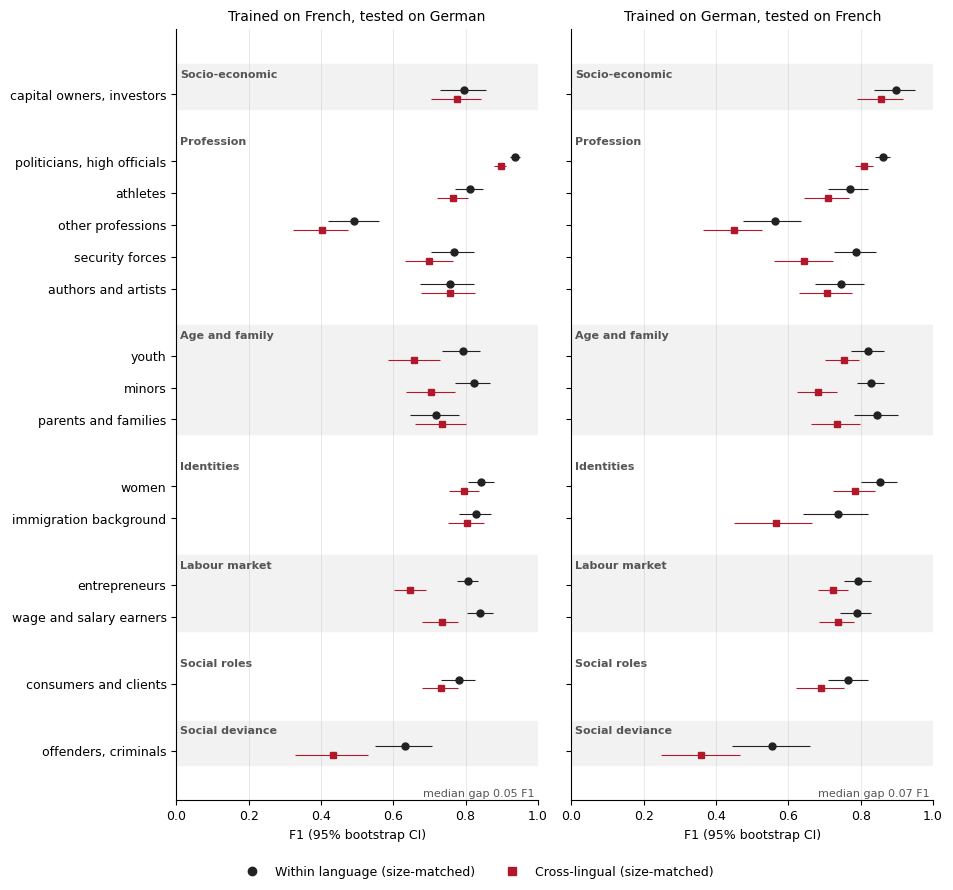

In [14]:
def label_layout(df):
    order = [s for _, s in CATEGORIES]
    labs = (df[["category", "hypothesis_label", "label_short", "min_both"]].drop_duplicates()
            .assign(co=lambda x: x.category.map(order.index))
            .sort_values(["co", "min_both"], ascending=[True, False]))
    ypos, y, prev, spans = [], 0.0, None, {}
    for cat in labs.category:
        if prev is not None and cat != prev: y += 1.1
        ypos.append(y); spans.setdefault(cat, []).append(y); y += 1; prev = cat
    return labs.reset_index(drop=True), ypos, spans

def shade(ax, spans):
    for i, (cat, ys) in enumerate(spans.items()):
        if i % 2 == 0: ax.axhspan(min(ys) - 0.95, max(ys) + 0.45, color="#F2F2F2", zorder=0)
        ax.text(0.01, min(ys) - 0.62, cat, transform=ax.get_yaxis_transform(), ha="left", va="center",
                fontsize=8, fontweight="bold", color="#555555")

pl = per_label[per_label.reportable & per_label.condition.isin(["within_matched", "cross_matched"])]
labs, ypos, spans = label_layout(pl)
fig, axes = plt.subplots(1, 2, figsize=(9.6, 0.42 * len(labs) + 2.6), sharey=True)
for ax, d in zip(axes, DIRS):
    shade(ax, spans)
    for (_, r), yy in zip(labs.iterrows(), ypos):
        s = pl[(pl.category == r.category) & (pl.hypothesis_label == r.hypothesis_label) & (pl.direction == d)].set_index("condition")
        if not {"within_matched", "cross_matched"} <= set(s.index): continue
        w, c = s.loc["within_matched"], s.loc["cross_matched"]
        ax.errorbar(w.f1_binary, yy - 0.14, xerr=[[w.f1_binary - w.f1_lo], [w.f1_hi - w.f1_binary]],
                    fmt="o", color=W_COL, ms=5, lw=0.8, zorder=3)
        ax.errorbar(c.f1_binary, yy + 0.14, xerr=[[c.f1_binary - c.f1_lo], [c.f1_hi - c.f1_binary]],
                    fmt="s", color=C_COL, ms=5, lw=0.8, zorder=3)
    g = gaps[gaps.reportable & (gaps.direction == d)]
    ax.text(0.99, 0.005, f"median gap {g.f1_gap.median():.2f} F1", transform=ax.transAxes, ha="right",
            fontsize=8, color="#555555")
    ax.set_title(TITLE[d], fontsize=10); ax.set_xlim(0.0, 1.0)
    ax.set_xlabel("F1 (95% bootstrap CI)"); ax.grid(axis="x", lw=0.4, alpha=0.5)
axes[0].set_yticks(ypos); axes[0].set_yticklabels(labs.label_short); axes[0].invert_yaxis()
fig.legend(handles=[Line2D([], [], marker="o", color=W_COL, ls="", label="Within language (size-matched)"),
                    Line2D([], [], marker="s", color=C_COL, ls="", label="Cross-lingual (size-matched)")],
           loc="lower center", ncol=2, frameon=False)
fig.tight_layout(rect=(0, 0.035, 1, 1))
for ext in ("png", "pdf"): fig.savefig(f"{OUT_DIR}/fig_crosslingual_f1.{ext}", dpi=300, bbox_inches="tight")
plt.show()

## 3b. Figure 1, all categories


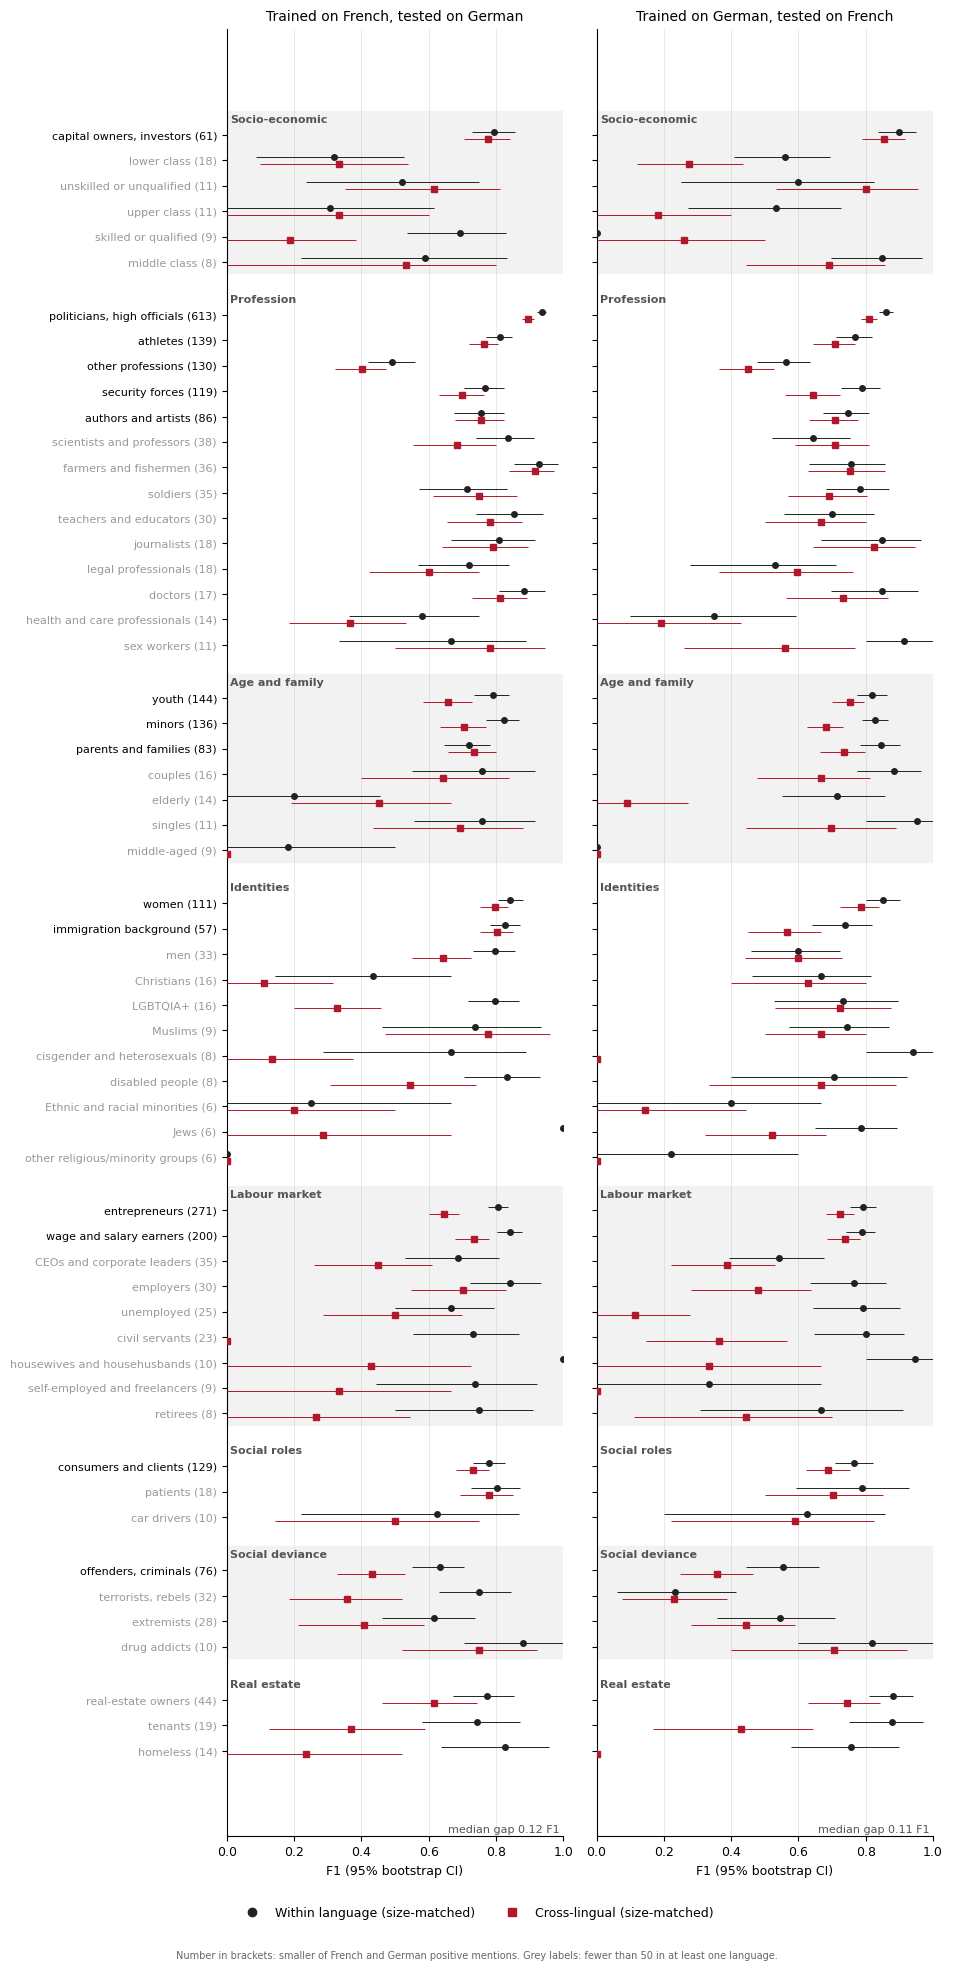

In [15]:
# ======= Figure 1, all specific labels (appendix version) =======
SHOW_LABELS = "all"        # "all" or "reportable"

pl = per_label[per_label.condition.isin(["within_matched", "cross_matched"])]
if SHOW_LABELS == "reportable":
    pl = pl[pl.reportable]
labs, ypos, spans = label_layout(pl)
fig, axes = plt.subplots(1, 2, figsize=(9.6, 0.30 * len(labs) + 2.6), sharey=True)
for ax, d in zip(axes, DIRS):
    shade(ax, spans)
    for (_, r), yy in zip(labs.iterrows(), ypos):
        s = pl[(pl.category == r.category) & (pl.hypothesis_label == r.hypothesis_label) & (pl.direction == d)].set_index("condition")
        if not {"within_matched", "cross_matched"} <= set(s.index): continue
        w, c = s.loc["within_matched"], s.loc["cross_matched"]
        ax.errorbar(w.f1_binary, yy - 0.14, xerr=[[w.f1_binary - w.f1_lo], [w.f1_hi - w.f1_binary]],
                    fmt="o", color=W_COL, ms=4, lw=0.7, zorder=3)
        ax.errorbar(c.f1_binary, yy + 0.14, xerr=[[c.f1_binary - c.f1_lo], [c.f1_hi - c.f1_binary]],
                    fmt="s", color=C_COL, ms=4, lw=0.7, zorder=3)
    g = gaps[gaps.direction == d] if SHOW_LABELS == "all" else gaps[gaps.reportable & (gaps.direction == d)]
    ax.text(0.99, 0.002, f"median gap {g.f1_gap.median():.2f} F1", transform=ax.transAxes, ha="right",
            fontsize=8, color="#555555")
    ax.set_title(TITLE[d], fontsize=10); ax.set_xlim(0.0, 1.0)
    ax.set_xlabel("F1 (95% bootstrap CI)"); ax.grid(axis="x", lw=0.4, alpha=0.5)
axes[0].set_yticks(ypos)
axes[0].set_yticklabels([f"{l} ({int(n)})" for l, n in zip(labs.label_short, labs.min_both)], fontsize=8)
rep = labs.merge(support[["category", "hypothesis_label", "reportable"]], on=["category", "hypothesis_label"], how="left")
for t, ok in zip(axes[0].get_yticklabels(), rep.reportable):
    t.set_color("black" if ok else "#999999")
axes[0].invert_yaxis()
fig.legend(handles=[Line2D([], [], marker="o", color=W_COL, ls="", label="Within language (size-matched)"),
                    Line2D([], [], marker="s", color=C_COL, ls="", label="Cross-lingual (size-matched)")],
           loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.35 / fig.get_figheight()))
fig.text(0.5, 0.08 / fig.get_figheight(), f"Number in brackets: smaller of French and German positive mentions. "
                      f"Grey labels: fewer than {MIN_POS} in at least one language.", fontsize=7, color="#666666", ha="center")
fig.tight_layout(rect=(0, 0.75 / fig.get_figheight(), 1, 1))
for ext in ("png", "pdf"): fig.savefig(f"{OUT_DIR}/fig_crosslingual_f1_all_labels.{ext}", dpi=300, bbox_inches="tight")
plt.show()

## 3c. Figure 1 alternative, paired F1 gap per label

1.   Listeneintrag
2.   Listeneintrag



One panel, both directions as two markers per label. Positive values mean the cross-lingual model is worse.
Filled markers indicate that the paired 95% interval excludes zero.

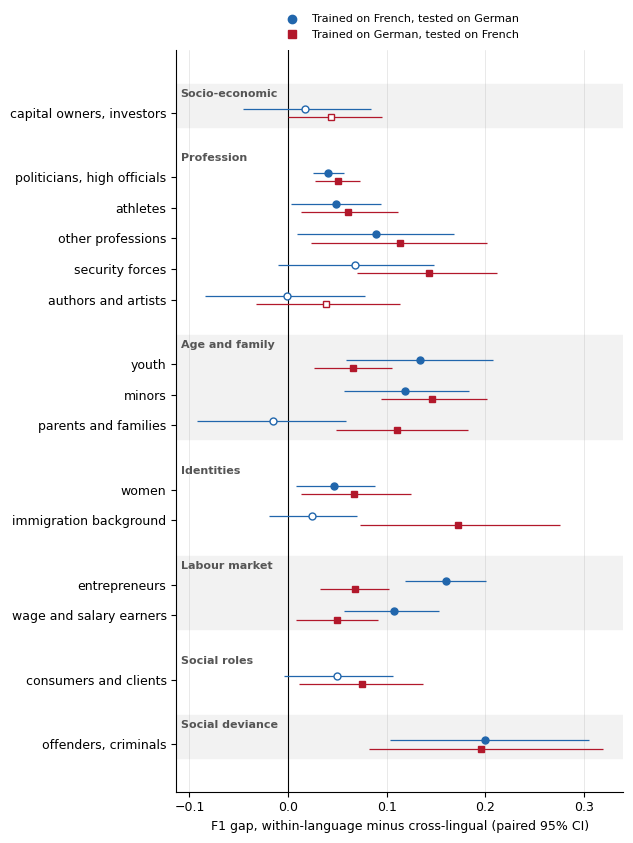

In [8]:
g = gaps[gaps.reportable]
labs, ypos, spans = label_layout(g)
fig, ax = plt.subplots(figsize=(6.4, 0.42 * len(labs) + 2.2))
shade(ax, spans)
style = {"fr2de": dict(marker="o", color="#2166AC", off=-0.14, label="Trained on French, tested on German"),
         "de2fr": dict(marker="s", color="#B2182B", off=0.14,  label="Trained on German, tested on French")}
for (_, r), yy in zip(labs.iterrows(), ypos):
    for d in DIRS:
        s = g[(g.category == r.category) & (g.hypothesis_label == r.hypothesis_label) & (g.direction == d)]
        if s.empty: continue
        s = s.iloc[0]; st = style[d]
        ax.errorbar(s.f1_gap, yy + st["off"], xerr=[[s.f1_gap - s.f1_gap_lo], [s.f1_gap_hi - s.f1_gap]],
                    fmt=st["marker"], color=st["color"], mfc=st["color"] if s.gap_ci_excludes_0 else "white",
                    ms=5, lw=0.9, zorder=3)
ax.axvline(0, color="black", lw=0.8)
ax.set_yticks(ypos); ax.set_yticklabels(labs.label_short); ax.invert_yaxis()
ax.set_xlabel("F1 gap, within-language minus cross-lingual (paired 95% CI)"); ax.grid(axis="x", lw=0.4, alpha=0.5)
ax.legend(handles=[Line2D([], [], marker=v["marker"], color=v["color"], ls="", label=v["label"]) for v in style.values()],
          loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=1, frameon=False, fontsize=8)
fig.tight_layout()
for ext in ("png", "pdf"): fig.savefig(f"{OUT_DIR}/fig_crosslingual_gaps.{ext}", dpi=300, bbox_inches="tight")
plt.show()

## 4. Figure 2, recall by similarity to the nearest training mention

Uses the per-mention similarity rows saved by each category notebook (`similarity_recall_rows.csv`).
`SIM_LABELS = "reportable"` keeps only the labels shown in Figure 1, so unstable small labels do not drive the curves.
`SIM_BINNING = "absolute"` uses shared similarity edges, with the last bin isolating near-duplicates
(within-language test sentences with an almost identical training sentence, which cross-lingual mentions cannot have).

In [9]:
sim = []
for folder, short in available:
    f = f"{xl_dir(folder)}/results/similarity_recall_rows.csv"
    if os.path.exists(f):
        s = pd.read_csv(f); s.insert(0, "category", short); sim.append(s)
    else:
        print(f"⚠️ {short}: no similarity_recall_rows.csv (similarity cell not run)")
sim = pd.concat(sim, ignore_index=True).dropna(subset=["max_sim"])
sim = sim.merge(support[["category", "hypothesis_label", "reportable"]], on=["category", "hypothesis_label"], how="left")
sim.to_csv(f"{OUT_DIR}/crosslingual_similarity_rows_all.csv", index=False)
print(f"{len(sim)} positive test mentions -> crosslingual_similarity_rows_all.csv")
print(f"share of mentions with similarity >= 0.95: " +
      ", ".join(f"{c} {sim[sim.condition == c].max_sim.ge(0.95).mean():.1%}" for c in ["within_matched", "cross_matched"]))

22593 positive test mentions -> crosslingual_similarity_rows_all.csv
share of mentions with similarity >= 0.95: within_matched 0.4%, cross_matched 0.0%


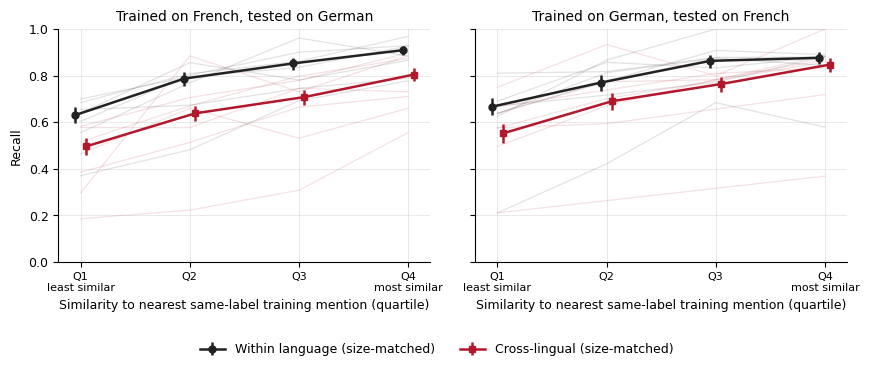

direction         de2fr                        fr2de               
condition cross_matched within_matched cross_matched within_matched
bin                                                                
0                 0.552          0.667         0.496          0.630
1                 0.690          0.770         0.638          0.787
2                 0.764          0.864         0.708          0.853
3                 0.848          0.877         0.804          0.909


In [10]:
def wilson(h, n, z=1.96):
    p = h / n; den = 1 + z * z / n; c = (p + z * z / (2 * n)) / den
    hw = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return c - hw, c + hw

S = sim[sim.condition.isin(["within_matched", "cross_matched"])].copy()
if SIM_LABELS == "reportable":
    S = S[S.reportable]
if SIM_BINNING == "quantile":
    S["bin"] = (S.groupby(["category", "direction", "condition"])["max_sim"]
                 .transform(lambda v: pd.qcut(v.rank(method="first"), N_QUANT, labels=False)))
    xt = [f"Q{i+1}" for i in range(N_QUANT)]; xt[0] += "\nleast similar"; xt[-1] += "\nmost similar"
    xlab = "Similarity to nearest same-label training mention (quartile)"
else:
    S["bin"] = pd.cut(S["max_sim"], SIM_EDGES, labels=False, right=False)
    xt = [f"{a:.2f}–{b:.2f}" if b <= 1 else f"≥{a:.2f}" for a, b in zip(SIM_EDGES[:-1], SIM_EDGES[1:])]
    xlab = "Cosine similarity to nearest same-label training mention"
nb = len(xt); x = np.arange(nb)

binned = (S.groupby(["direction", "condition", "bin"]).agg(hits=("hit", "sum"), n=("hit", "size")).reset_index())
binned["recall"] = binned.hits / binned.n
binned[["lo", "hi"]] = binned.apply(lambda r: pd.Series(wilson(r.hits, r.n)), axis=1)
binned.to_csv(f"{OUT_DIR}/crosslingual_similarity_bins_pooled.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.5), sharey=True)
for ax, d in zip(axes, DIRS):
    for cond, col, mk, off, lab in [("within_matched", W_COL, "o", -0.05, "Within language (size-matched)"),
                                    ("cross_matched",  C_COL, "s",  0.05, "Cross-lingual (size-matched)")]:
        for cat, cs in S[(S.direction == d) & (S.condition == cond)].groupby("category"):   # faint per-category lines
            r = cs.groupby("bin")["hit"].mean().reindex(range(nb))
            ax.plot(x, r.values, color=col, alpha=0.13, lw=0.9)
        b = binned[(binned.direction == d) & (binned.condition == cond)].set_index("bin").reindex(range(nb))
        ax.errorbar(x + off, b.recall, yerr=[b.recall - b.lo, b.hi - b.recall], color=col, marker=mk, ms=5, lw=1.8,
                    capsize=0, label=lab)
        if SIM_BINNING == "absolute":
            for xi, n in zip(x, b.n): ax.text(xi + off, 0.02 if cond == "within_matched" else 0.07,
                                              "" if pd.isna(n) else f"n={int(n)}", ha="center", fontsize=6, color=col)
    ax.set_xticks(x); ax.set_xticklabels(xt, fontsize=8); ax.set_ylim(0, 1)
    ax.set_title(TITLE[d], fontsize=10); ax.set_xlabel(xlab); ax.grid(lw=0.4, alpha=0.5)
axes[0].set_ylabel("Recall")
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.06))
fig.tight_layout(rect=(0, 0.06, 1, 1))
for ext in ("png", "pdf"): fig.savefig(f"{OUT_DIR}/fig_crosslingual_similarity.{ext}", dpi=300, bbox_inches="tight")
plt.show()
print(binned.pivot_table(index="bin", columns=["direction", "condition"], values="recall").round(3).to_string())

8 categories, 57 labels, 15062 positive test mentions


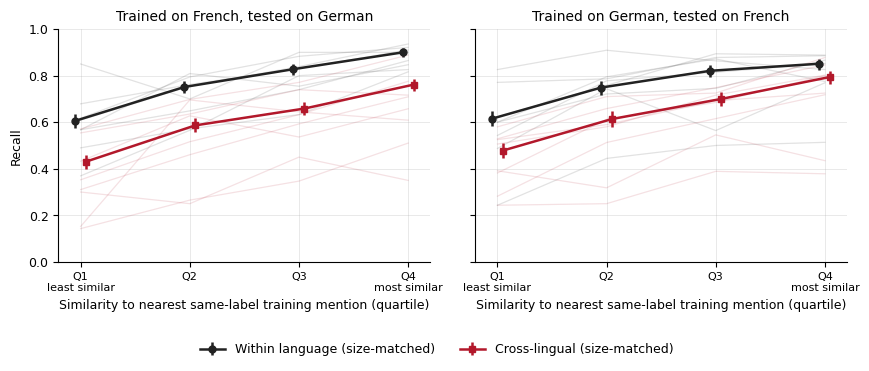

direction         de2fr                        fr2de               
condition cross_matched within_matched cross_matched within_matched
bin                                                                
0                 0.478          0.615         0.431          0.606
1                 0.614          0.749         0.586          0.751
2                 0.700          0.821         0.659          0.828
3                 0.795          0.851         0.761          0.900


In [16]:
def wilson(h, n, z=1.96):
    p = h / n; den = 1 + z * z / n; c = (p + z * z / (2 * n)) / den
    hw = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return c - hw, c + hw

SIM_LABELS_FIG = "all"          # "all" = every label in all eight categories, "reportable" = only labels >= MIN_POS
suffix = "_all_labels" if SIM_LABELS_FIG == "all" else ""

S = sim[sim.condition.isin(["within_matched", "cross_matched"])].copy()
if SIM_LABELS_FIG == "reportable":
    S = S[S.reportable]
print(f"{S.category.nunique()} categories, {S.groupby(['category','hypothesis_label']).ngroups} labels, "
      f"{len(S)} positive test mentions")

if SIM_BINNING == "quantile":
    S["bin"] = (S.groupby(["category", "direction", "condition"])["max_sim"]
                 .transform(lambda v: pd.qcut(v.rank(method="first"), N_QUANT, labels=False)))
    xt = [f"Q{i+1}" for i in range(N_QUANT)]; xt[0] += "\nleast similar"; xt[-1] += "\nmost similar"
    xlab = "Similarity to nearest same-label training mention (quartile)"
else:
    S["bin"] = pd.cut(S["max_sim"], SIM_EDGES, labels=False, right=False)
    xt = [f"{a:.2f}–{b:.2f}" if b <= 1 else f"≥{a:.2f}" for a, b in zip(SIM_EDGES[:-1], SIM_EDGES[1:])]
    xlab = "Cosine similarity to nearest same-label training mention"
nb = len(xt); x = np.arange(nb)

binned = (S.groupby(["direction", "condition", "bin"]).agg(hits=("hit", "sum"), n=("hit", "size")).reset_index())
binned["recall"] = binned.hits / binned.n
binned[["lo", "hi"]] = binned.apply(lambda r: pd.Series(wilson(r.hits, r.n)), axis=1)
binned.to_csv(f"{OUT_DIR}/crosslingual_similarity_bins_pooled{suffix}.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.5), sharey=True)
for ax, d in zip(axes, DIRS):
    for cond, col, mk, off, lab in [("within_matched", W_COL, "o", -0.05, "Within language (size-matched)"),
                                    ("cross_matched",  C_COL, "s",  0.05, "Cross-lingual (size-matched)")]:
        for cat, cs in S[(S.direction == d) & (S.condition == cond)].groupby("category"):   # faint per-category lines
            r = cs.groupby("bin")["hit"].mean().reindex(range(nb))
            ax.plot(x, r.values, color=col, alpha=0.13, lw=0.9)
        b = binned[(binned.direction == d) & (binned.condition == cond)].set_index("bin").reindex(range(nb))
        ax.errorbar(x + off, b.recall, yerr=[b.recall - b.lo, b.hi - b.recall], color=col, marker=mk, ms=5, lw=1.8,
                    capsize=0, label=lab)
        if SIM_BINNING == "absolute":
            for xi, n in zip(x, b.n): ax.text(xi + off, 0.02 if cond == "within_matched" else 0.07,
                                              "" if pd.isna(n) else f"n={int(n)}", ha="center", fontsize=6, color=col)
    ax.set_xticks(x); ax.set_xticklabels(xt, fontsize=8); ax.set_ylim(0, 1)
    ax.set_title(TITLE[d], fontsize=10); ax.set_xlabel(xlab); ax.grid(lw=0.4, alpha=0.5)
axes[0].set_ylabel("Recall")
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.06))
fig.tight_layout(rect=(0, 0.06, 1, 1))
for ext in ("png", "pdf"): fig.savefig(f"{OUT_DIR}/fig_crosslingual_similarity{suffix}.{ext}", dpi=300, bbox_inches="tight")
plt.show()
print(binned.pivot_table(index="bin", columns=["direction", "condition"], values="recall").round(3).to_string())

## 5. Overview figure, all categories in both directions

One row per broad category. F1 is micro-averaged over **all** specific labels of the category (every sentence by label
pair counts once), so it reflects how well the category model as a whole transfers, including small labels.
Intervals are paired bootstrap intervals that resample sentences, keeping all labels of a sentence together.
The number on the right is the cross-lingual F1 as a share of the within-language F1.

In [11]:
def micro_f1(y, s):
    yhat = s > 0.5
    tp = (y & yhat).sum(-1); fp = (~y & yhat).sum(-1); fn = (y & ~yhat).sum(-1)
    return np.where(2 * tp + fp + fn > 0, 2 * tp / np.maximum(2 * tp + fp + fn, 1), np.nan)

rng = np.random.RandomState(SEED)
cat_rows = []
for folder, short in available:
    W = load_condition_preds(folder, "within_matched"); C = load_condition_preds(folder, "cross_matched")
    if W.empty or C.empty: continue
    key = ["direction", "hypothesis_label", "sentence_id"]
    m = W[key + ["nli_label", "prob_entail"]].merge(C[key + ["prob_entail"]], on=key, suffixes=("_w", "_c"))
    for d, g in m.groupby("direction"):
        # sentence x label matrices, so the bootstrap resamples whole sentences
        Y  = g.pivot(index="sentence_id", columns="hypothesis_label", values="nli_label").eq(0).values
        SW = g.pivot(index="sentence_id", columns="hypothesis_label", values="prob_entail_w").values
        SC = g.pivot(index="sentence_id", columns="hypothesis_label", values="prob_entail_c").values
        y, sw, sc = Y.ravel(), np.nan_to_num(SW).ravel(), np.nan_to_num(SC).ravel()
        fw, fc = float(micro_f1(y, sw)), float(micro_f1(y, sc))
        idx = rng.randint(0, Y.shape[0], size=(N_BOOT, Y.shape[0]))
        yb  = Y[idx].reshape(N_BOOT, -1)
        bw  = micro_f1(yb, np.nan_to_num(SW)[idx].reshape(N_BOOT, -1))
        bc  = micro_f1(yb, np.nan_to_num(SC)[idx].reshape(N_BOOT, -1))
        q = lambda a: np.nanpercentile(a, [2.5, 97.5])
        mac = per_label[(per_label.category == short) & (per_label.direction == d)].pivot_table(
            index="hypothesis_label", columns="condition", values="f1_binary")
        cat_rows.append(dict(category=short, direction=d, n_labels=Y.shape[1], n_test_sentences=Y.shape[0],
                             n_test_pos=int(Y.sum()),
                             microf1_within=fw, microf1_within_lo=q(bw)[0], microf1_within_hi=q(bw)[1],
                             microf1_cross=fc,  microf1_cross_lo=q(bc)[0],  microf1_cross_hi=q(bc)[1],
                             microf1_gap=fw - fc, microf1_gap_lo=q(bw - bc)[0], microf1_gap_hi=q(bw - bc)[1],
                             retention=fc / fw if fw > 0 else np.nan,
                             macrof1_within=mac.get("within_matched", pd.Series(dtype=float)).mean(),
                             macrof1_cross=mac.get("cross_matched", pd.Series(dtype=float)).mean()))
cats = pd.DataFrame(cat_rows)
cats.to_csv(f"{OUT_DIR}/crosslingual_category_overview.csv", index=False)
print(cats.round(3).to_string(index=False))

       category direction  n_labels  n_test_sentences  n_test_pos  microf1_within  microf1_within_lo  microf1_within_hi  microf1_cross  microf1_cross_lo  microf1_cross_hi  microf1_gap  microf1_gap_lo  microf1_gap_hi  retention  macrof1_within  macrof1_cross
 Socio-economic     de2fr         6              3485         156           0.714              0.649              0.771          0.617             0.544             0.679        0.097           0.034           0.163      0.864           0.573          0.510
 Socio-economic     fr2de         6              3749         183           0.696              0.637              0.749          0.621             0.555             0.683        0.075           0.010           0.138      0.892           0.538          0.463
     Profession     de2fr        14              3485        1323           0.785              0.768              0.802          0.723             0.702             0.742        0.062           0.044           0.080      0.921

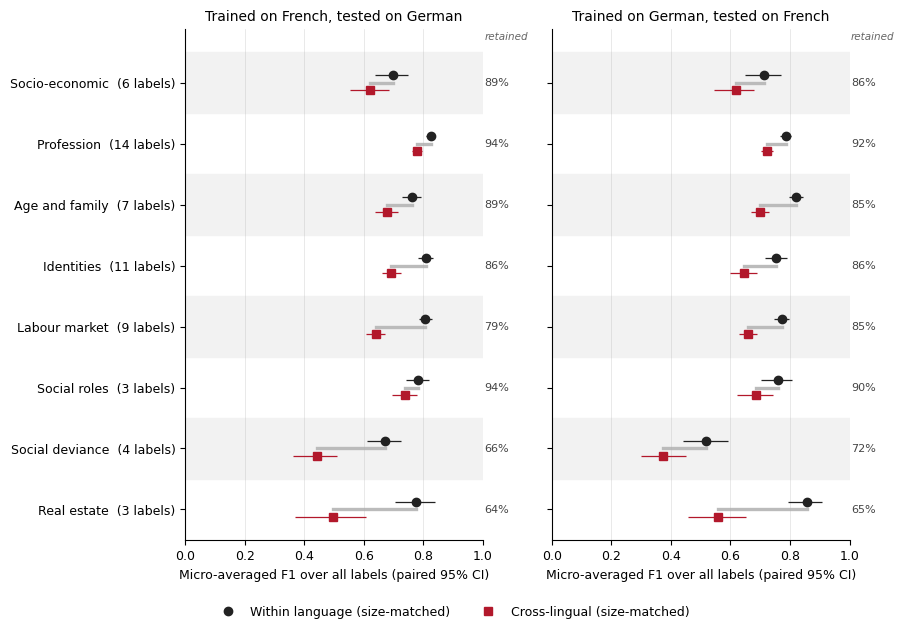

In [12]:
order = [s for _, s in CATEGORIES if s in set(cats.category)]
fig, axes = plt.subplots(1, 2, figsize=(9.4, 0.55 * len(order) + 1.9), sharey=True)
for ax, d in zip(axes, DIRS):
    c = cats[cats.direction == d].set_index("category").reindex(order)
    y = np.arange(len(order))
    for i, (cat, r) in enumerate(c.iterrows()):
        if i % 2 == 0: ax.axhspan(i - 0.5, i + 0.5, color="#F2F2F2", zorder=0)
        if pd.isna(r.microf1_within): continue
        ax.plot([r.microf1_cross, r.microf1_within], [i, i], color="#BBBBBB", lw=2.4, zorder=1)
        ax.errorbar(r.microf1_within, i - 0.12, xerr=[[r.microf1_within - r.microf1_within_lo], [r.microf1_within_hi - r.microf1_within]],
                    fmt="o", color=W_COL, ms=6, lw=0.9, zorder=3)
        ax.errorbar(r.microf1_cross, i + 0.12, xerr=[[r.microf1_cross - r.microf1_cross_lo], [r.microf1_cross_hi - r.microf1_cross]],
                    fmt="s", color=C_COL, ms=6, lw=0.9, zorder=3)
        sig = "" if r.microf1_gap_lo > 0 or r.microf1_gap_hi < 0 else " (n.s.)"
        ax.text(1.005, i, f"{r.retention:.0%}{sig}", transform=ax.get_yaxis_transform(), va="center", fontsize=8, color="#444444")
    ax.text(1.005, -0.75, "retained", transform=ax.get_yaxis_transform(), va="center", fontsize=7.5,
            fontstyle="italic", color="#666666")
    ax.set_title(TITLE[d], fontsize=10); ax.set_xlim(0.0, 1.0); ax.grid(axis="x", lw=0.4, alpha=0.5)
    ax.set_xlabel("Micro-averaged F1 over all labels (paired 95% CI)")
axes[0].set_yticks(np.arange(len(order)))
axes[0].set_yticklabels([f"{c}  ({int(cats[(cats.category == c)].n_labels.max())} labels)" for c in order])
axes[0].invert_yaxis()
fig.legend(handles=[Line2D([], [], marker="o", color=W_COL, ls="", label="Within language (size-matched)"),
                    Line2D([], [], marker="s", color=C_COL, ls="", label="Cross-lingual (size-matched)")],
           loc="lower center", ncol=2, frameon=False)
fig.tight_layout(rect=(0, 0.05, 0.97, 1))
for ext in ("png", "pdf"): fig.savefig(f"{OUT_DIR}/fig_crosslingual_overview.{ext}", dpi=300, bbox_inches="tight")
plt.show()

## 6. Appendix heatmap, every specific label in every category

All labels, not only reportable ones, so nothing is left out. Columns show within-language F1, cross-lingual F1 and
their gap for each direction. Labels below `MIN_POS` are shown in grey; the number after each label is the smaller of
its French and German positive counts.

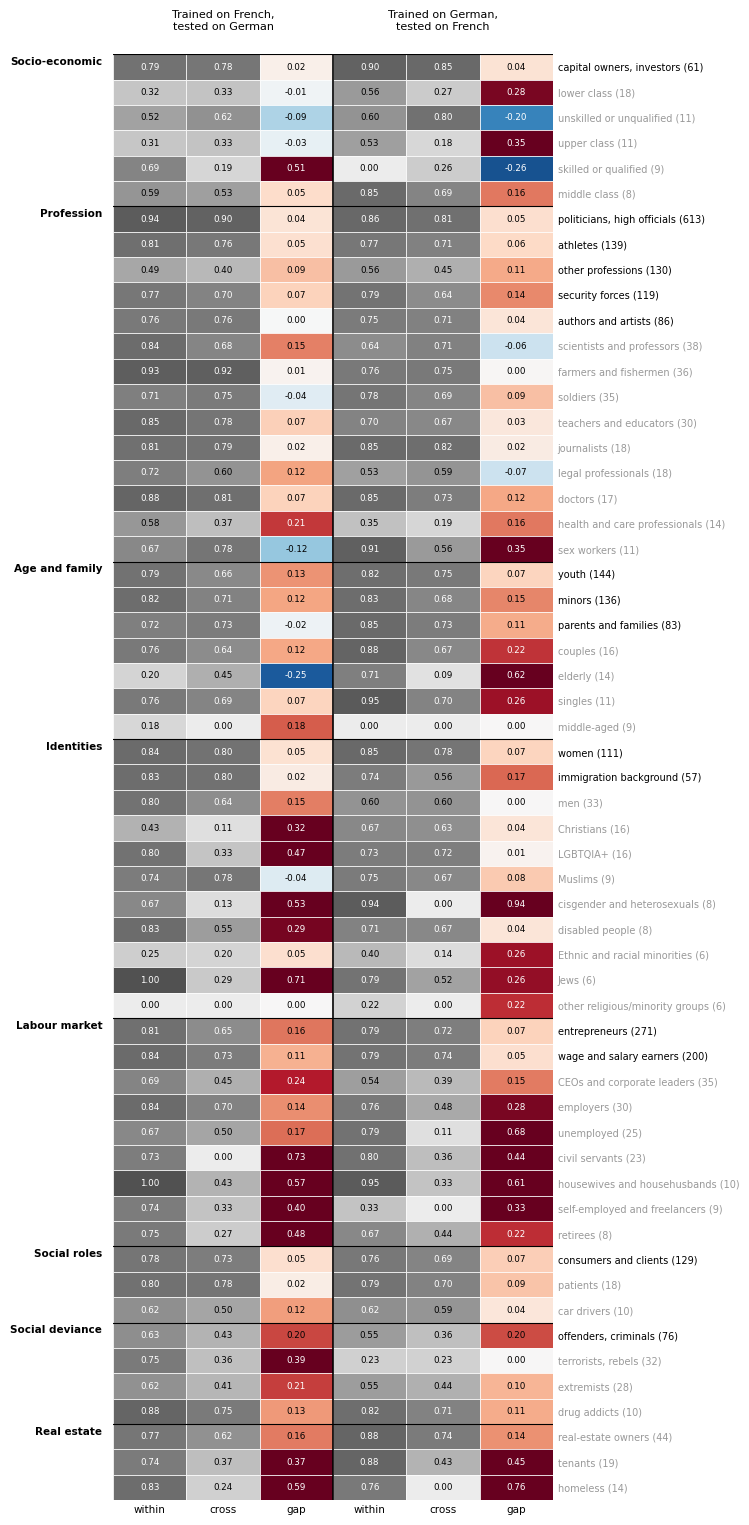

In [13]:
import matplotlib.colors as mcolors
H = per_label[per_label.condition.isin(["within_matched", "cross_matched"])]
H = H.pivot_table(index=["category", "hypothesis_label", "label_short", "min_both", "reportable"],
                  columns=["direction", "condition"], values="f1_binary").reset_index()
H.columns = pd.Index([c[0] if c[1] == "" else c for c in H.columns], tupleize_cols=False)
ordc = [s for _, s in CATEGORIES]
H["co"] = H.category.map(ordc.index)
H = H.sort_values(["co", "min_both"], ascending=[True, False]).reset_index(drop=True)
cols = []
for d in DIRS:
    cols += [((d, "within_matched")), ((d, "cross_matched")), ((d, "gap"))]
    H[(d, "gap")] = H[(d, "within_matched")] - H[(d, "cross_matched")]
M = np.column_stack([H[c].values for c in cols]).astype(float)

fig, ax = plt.subplots(figsize=(7.6, 0.24 * len(H) + 1.6))
f1_cmap = plt.get_cmap("Greys"); gap_cmap = plt.get_cmap("RdBu_r")
gap_norm = mcolors.TwoSlopeNorm(vmin=-0.3, vcenter=0, vmax=0.3)
for j, c in enumerate(cols):
    for i in range(len(H)):
        v = M[i, j]
        if np.isnan(v): col = "white"
        elif c[1] == "gap": col = gap_cmap(gap_norm(np.clip(v, -0.3, 0.3)))
        else: col = f1_cmap(0.15 + 0.6 * v)
        ax.add_patch(plt.Rectangle((j, i), 1, 1, color=col, ec="white", lw=0.5))
        if not np.isnan(v):
            dark = (c[1] != "gap" and v > 0.6) or (c[1] == "gap" and abs(v) > 0.2)
            ax.text(j + 0.5, i + 0.5, f"{0.0 if abs(v) < 0.005 else v:.2f}", ha="center", va="center", fontsize=6.3, color="white" if dark else "black")
# category separators and labels
prev = None
for i, cat in enumerate(H.category):
    if cat != prev:
        ax.axhline(i, color="black", lw=0.8)
        ax.text(-0.15, i + 0.1, cat, ha="right", va="top", fontsize=7.5, fontweight="bold", transform=ax.transData)
        prev = cat
ax.set_xlim(0, len(cols)); ax.set_ylim(len(H), 0)
ax.set_yticks(np.arange(len(H)) + 0.5)
ax.set_yticklabels([f"{l} ({int(n)})" for l, n in zip(H["label_short"], H["min_both"])], fontsize=7)
ax.yaxis.tick_right()
for tk, rep in zip(ax.yaxis.get_major_ticks(), H["reportable"]):
    tk.label2.set_color("black" if rep else "#999999")
ax.set_xticks(np.arange(len(cols)) + 0.5)
ax.set_xticklabels(["within", "cross", "gap"] * 2, fontsize=7.5)
ax.tick_params(length=0)
for k, d in enumerate(DIRS):
    ax.text(1.5 + 3 * k, -0.9, TITLE[d].replace(", ", ",\n"), ha="center", va="bottom", fontsize=8)
ax.axvline(3, color="black", lw=1.2)
for sp in ax.spines.values(): sp.set_visible(False)
fig.tight_layout()
for ext in ("png", "pdf"): fig.savefig(f"{OUT_DIR}/fig_crosslingual_heatmap_all_labels.{ext}", dpi=300, bbox_inches="tight")
plt.show()